# Tax-loss harvesting — the "free money" your robo-advisor promises 🧾
### Real arithmetic, not market magic — and for some people, exactly zero

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Who_gets_zero%3F: Confirmed](https://img.shields.io/badge/Who_gets_zero%3F-Confirmed-8b949e?style=flat-square)

Every robo-advisor pitch says the same thing: *"our software watches your account every day, sells anything that's down, instantly buys a **twin fund** so you stay invested, and the harvested loss cuts your tax bill — an extra **0.3–1% a year**, for free."*

It sounds like a perpetual-motion machine. It isn't — but it isn't a scam either. It's **tax arithmetic**: you stay 100% invested the whole time (the twin fund moves with the market just like the original), so the market can't be where the money comes from. The money comes from **your own tax rates** — and that has three consequences this notebook walks through: the gain is real, it's **front-loaded**, and if your tax rate is zero, your share is *exactly nothing minus costs*.

> 📓 **Plain-language layer.** Want the lot-level engine, the HAC *t*-stats and the rate grid? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Scope note.** We test the claim on a single broad-index fund (SPY, with IVV as the twin) — the plain-vanilla robo setup. Stock-level "direct indexing" harvests more (see the references). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md). *Not tax advice.*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab)
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tax_loss_harvesting import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    SPY, IVV = data.load_real()
else:
    SPY = IVV = None
print("real SPY cache present:", HAVE_REAL,
      "| days:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-01-29', 'end': '2026-06-30', 'n_days': 8411, 'years': 33.4, 'fingerprint': 'cb2440086a51', 'twin_corr': 0.9932, 'twin_gap_bps': 0.01, 'twin_te_bps': 223, 'twin_days': 6565, 'lump_harvests': 0, 'lump_alpha': 0.0, 'grid': [('35/15 (top bracket, ST offsets)', 13.1, 4.49, 667), ('24/15 (middle bracket)', 8.8, 3.0, 667), ('15/15 (deferral only)', 5.4, 1.82, 667), ('35/15 + step-up at death', 13.9, 4.75, 667), ('0/0 (0% bracket — myth check)', -0.4, -0.13, 667), ('0/0 + step-up (low-bracket donor)', -0.4, -0.13, 667)], 'harvested_total': 55216, 'st_share': 88.5, 'tax_saved': 18057, 'term_tax_tlh': 544694, 'term_tax_bh': 511804, 'n_cohorts': 94, 'co_mean': 46.0, 'co_median': 23.5, 'co_sd': 53.9, 'co_min': -0.4, 'co_max': 189.0, 'hac_t': 2.88, 'hac_lag': 40, 'share_pos': 73.4, 'zero_harvest': 24, 'best_start': '2007-10-01', 'worst_start': '2010-10-01', 'decade_means': '1990s +13.2, 2000s +90.8, 2010s +12.5 bps/yr', 'co_grid': [('35/15', 46.0, 23.5, 2.88), ('24/15', 27.5, 14.7, 2.78), ('15/15', 12.3, 6.2, 2.42)], 'bear_mean': 2.23, 'calm_mean': 0.16, 'welch_t': 2.72, 'welch_dof': 6.1, 'bear_years': (2000, 2001, 2002, 2008, 2009, 2020, 2022), 'rich_years': '2008: 4.80%, 2002: 4.29%, 2009: 2.95%, 2001: 2.93%, 1994: 1.33%, 2003: 0.90%', 'decay': [6.57, 3.19, 2.58, 1.81, 1.6, 0.46, 0.19, 0.15, 0.15, 0.17], 'decay_tail': 0.17, 'thresholds': [(0.5, 45.7, 2.94, 4.3), (1.0, 46.0, 2.88, 4.3), (5.0, 48.8, 2.93, 2.5)], 'syn': [(0.02, 0.09, 0.4, -0.02), (0.18, 47.0, 47.7, -2.67), (0.35, 128.45, 104.5, -4.33)]}


real SPY cache present: True | days: 8411


## The answer first

| Question | Answer |
|---|---|
| Does harvesting add after-tax return? | **Yes — really.** The mean 10-year cohort banks **+46 bps/yr** at top-bracket rates (statistically solid — the quants notebook has HAC *t* = +2.88). |
| Is it the advertised 0.3–1%/yr? | **Only at the top.** The *median* cohort gets **+24 bps/yr**, and a 33-year steady saver nets **+13 bps/yr**. |
| Where does the money come from? | **Your own tax rates** — deduct losses at ~35%, repay gains later at ~15%, plus deferral. Set both rates to zero and the "alpha" is **−0.4 bps/yr** (pure trading costs). |
| Does it last? | **No — it fades.** Year-1 harvest ≈ **6.6%** of your stake; by years 7–10 it's ≈ **0.17%/yr**. Old money stops harvesting. |
| Who gets zero? | The **0%-bracket** retiree or donor — including with step-up at death. A quarter of 10-year cohorts never harvest *at all*. |

## What a "harvest" actually is

Say you bought an S&P 500 fund at \$100 and it drops to \$90. You now own the same market exposure either way — but if you **sell**, the \$10 loss becomes a *realised* loss the tax code lets you deduct against gains elsewhere. So the machine sells, immediately buys a **twin fund** (a different issuer's S&P 500 ETF — SPY↔IVV — so the *wash-sale rule* doesn't void the loss), and you keep riding the market as if nothing happened. At ~35% short-term rates, that \$10 loss puts **\$3.50** back in your pocket today.

The catch nobody advertises: your new lot's cost basis is now **\$90**, so when you finally sell, your taxable gain is \$10 **bigger**. You didn't erase tax — you **moved it in time** (deferral) and **changed its rate** (deduct at 35%, repay at 15%). That spread — not the market — is the entire product.

Below: the tape we run it on — every day from 1993 to 2026, a lot-level simulator checks a steady saver's account ($10k start + $1k/month) and harvests any lot down more than 1%.

after-tax alpha +13.1 bps/yr over 33.4 years | 667 harvests | tax savings reinvested $18,057


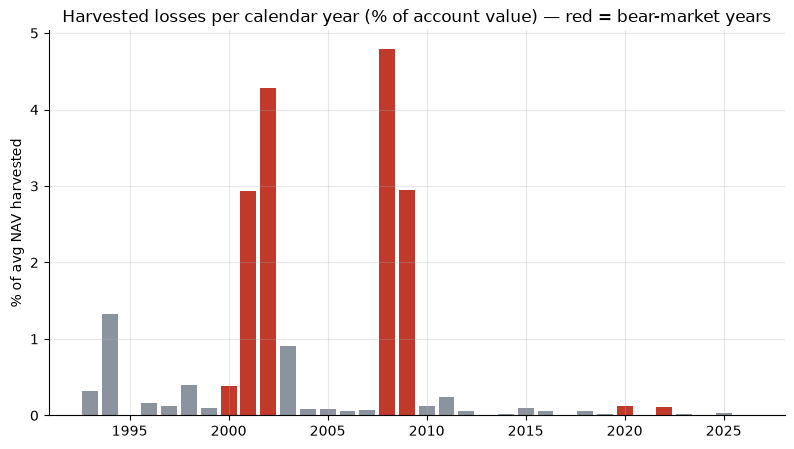

In [2]:
# the harvest calendar — when does the machine actually find losses?
if HAVE_REAL:
    r = st.after_tax_alpha(SPY, initial=10_000, monthly_contrib=1_000,
                           st_rate=0.35, lt_rate=0.15)
    hy = st.harvest_yield_by_year(r['h'])
    fig, ax = plt.subplots()
    colors = [RED if y in R['bear_years'] else GREY for y in hy.index]
    ax.bar(hy.index, hy.values, color=colors)
    ax.set_title('Harvested losses per calendar year (% of account value) — '
                 'red = bear-market years')
    ax.set_ylabel('% of avg NAV harvested')
    print(f"after-tax alpha {r['alpha_bps']:+.1f} bps/yr over {r['years']:.1f} years "
          f"| {r['h']['n_harvests']} harvests | tax savings reinvested "
          f"${r['h']['tax_saved']:,.0f}")
else:
    print('cache missing — quoting docs/results.md: alpha +13.1 bps/yr, 667 harvests')


**Read the chart:** the machine feasts in **2000–02, 2008–09** (and nibbles in 1994, 2020, 2022) and starves in every calm bull year — 2013, 2017, 2021, 2024 harvest essentially **nothing**. Tax-loss harvesting is a **bear-market crop**: the quants notebook shows bear years yield **~14×** the calm years (2.2% vs 0.16% of NAV per year).

> 🔬 **For the quants.** The engine is lot-level: every contribution, harvest repurchase and reinvested tax saving opens its own lot with its own basis and clock; losses are classified short/long-term; execution is at the **next** close (one lag); 2 bps one-way costs per leg; both books pay per-lot capital-gains tax at the end.

## Where the money comes from — run the same tape at different tax rates

Same market, same 667 harvests, same everything — only the investor's tax bracket changes:

| rate pair (ST/LT) | after-tax alpha (bps/yr) | terminal uplift |
|---|--:|--:|
| 35/15 (top bracket, ST offsets) | **+13.1** | +4.49% |
| 24/15 (middle bracket) | **+8.8** | +3.00% |
| 15/15 (deferral only) | **+5.4** | +1.82% |
| 35/15 + step-up at death | **+13.9** | +4.75% |
| 0/0 (0% bracket — myth check) | **-0.4** | -0.13% |
| 0/0 + step-up (low-bracket donor) | **-0.4** | -0.13% |

The market path is identical in every row. The **entire** payoff is the rate pair: a top-bracket investor with short-term gains to offset keeps ~13 bps/yr; equal rates (pure deferral) keep ~5; a **0% bracket keeps less than nothing** (the trading costs). This is the cleanest possible proof that TLH is *arithmetic, not alpha*.

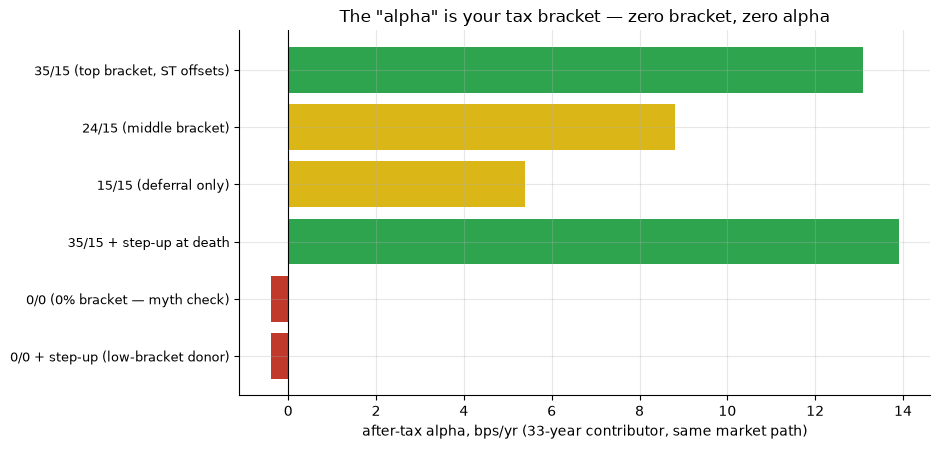

In [3]:
labels = [g[0] for g in R['grid']]
vals = [g[1] for g in R['grid']]
cols = [GREEN if v > 10 else (AMBER if v > 0 else RED) for v in vals]
fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.barh(range(len(vals))[::-1], vals, color=cols)
ax.set_yticks(range(len(vals))[::-1]); ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('after-tax alpha, bps/yr (33-year contributor, same market path)')
ax.set_title('The "alpha" is your tax bracket — zero bracket, zero alpha')
plt.tight_layout()


## The machine goes quiet — basis lock-up

A loss needs a price **below what you paid**. After a few years of normal market growth, everything you own sits far above its purchase price, and even a nasty crash (2020: −34% in a month!) barely dents lots bought years earlier. Fresh cash is the only thing that keeps the machine fed — which is why the robo pitch quietly assumes you keep contributing forever. A **1993 lump sum never harvests again** after its first weeks: zero harvests in 33 years.

Text(0.5, 1.0, 'The harvest fades as your basis locks up: 6.6% in year 1 → 0.17%/yr by years 7-10')

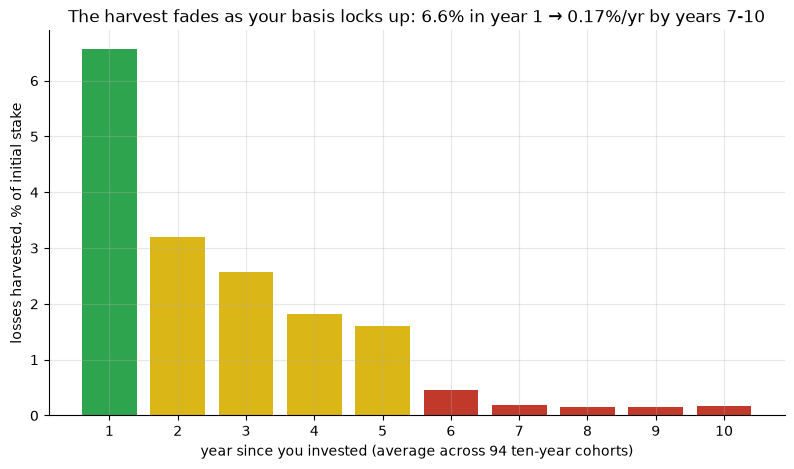

In [4]:
yrs = np.arange(1, 11)
fig, ax = plt.subplots()
ax.bar(yrs, R['decay'], color=[GREEN]+[AMBER]*4+[RED]*5)
ax.set_xticks(yrs)
ax.set_xlabel('year since you invested (average across 94 ten-year cohorts)')
ax.set_ylabel('losses harvested, % of initial stake')
ax.set_title('The harvest fades as your basis locks up: '
             f"{R['decay'][0]:.1f}% in year 1 → {R['decay_tail']:.2f}%/yr by years 7-10")


## The verdict

**Real** — the after-tax gain is genuine arithmetic and shows up on 33 years of real tape: **+46 bps/yr** on the mean 10-year cohort at top-bracket rates, statistically solid. **Fragile** — it's front-loaded, bear-market-fed (24 of 94 cohorts get *nothing*), needs short-term gains elsewhere to offset, and the median cohort's **+24 bps** is *less than the 25 bps fee* many robos charge to do it for you. **Who gets zero? — confirmed:** at a 0% tax rate the machine produces exactly **−0.4 bps/yr** (its own trading costs), step-up or not.

**Take-away:** if you're in a high bracket, harvest — especially in the first years and in crashes, and ideally yourself, for free. If you're in a low bracket, donating, or holding until step-up: the robo is harvesting **its fee**, not your alpha.

*Full stats, engine spec and robustness: [02_for_the_quants.ipynb](02_for_the_quants.ipynb) · numbers: [docs/results.md](../docs/results.md) · sources: [docs/references.md](../docs/references.md). Not investment or tax advice.*